In [30]:
#!/usr/bin/env python3
# coding: utf-8

"""
File: optimization_manager.py
Author: Matthew Ogden
Email: ogdenm12@gmail.com
Github: mbogden
Created: 2024-Nov-11

References:  Sections of this code were enhanced with the assistance of ChatGPT made by OpenAI.
"""

# ================================ STANDARD IMPORTS ================================ #
import logging
import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# partial imports
from mpi4py import MPI
from skopt import Optimizer
from skopt.space import Real
from skopt.sampler import Lhs, Sobol

# ================================ PROJECT MODULES ================================ #
# Add main project directory to import project modules
try:
    SCRIPT_DIRECTORY = os.path.dirname(os.path.realpath(__file__))
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    sys.path.append(PROJECT_DIRECTORY)

except:
    # Assume we are running from the script directory
    SCRIPT_DIRECTORY = os.getcwd()
    PROJECT_DIRECTORY = os.path.dirname(SCRIPT_DIRECTORY)
    
    # Also assume you might be in galStuff
    work_dir = os.getcwd()
    if 'galStuff' == work_dir.split('/')[-1]:
        PROJECT_DIRECTORY =  work_dir + '/galaxyJSPAM'
        sys.path.append(PROJECT_DIRECTORY)

# import project modules
import utilities.general_utility as gu
import utilities.parallel_queue_manager as qm

# ================================ GLOBAL VARIABLES ================================ #
buildEnv = False

# Global logger from main program
SCRIPTS_ARGUMENTS, logger = gu.initialize_environment(module_name='optimizer') # Testing using multiple loggers for tiered log levels.
# SCRIPTS_ARGUMENTS, logger = gu.initialize_environment(module_name='') 

# Generate random instance
rng = np.random.default_rng()

In [31]:
# Development Cell:  This should only be present in the Jupyter Notebook version of this script for development purposes.
buildEnv = True

from importlib import reload

# Warn user if NOT in jupyter notebook, require a yes/no response to continue or not
if "ipykernel" not in sys.modules:
    msg = "Development Environment Detected.  This will run several tests and attempt to creat plots.  Do you want to continue?..."

    # Get user input
    while True:
        response = input(f"{msg} (y/n): ").lower()
        if response in ['y', 'yes']:
            break
        elif response in ['n', 'no']:
            print("Exiting...")
            sys.exit()
        else:
            print("Invalid input. Please enter 'y' or 'n'.")



[2025-03-03 14:07:20,731 - INFO - 3093852918.test_space_manager]: Testing Space Manager
[2025-03-03 14:07:20,732 - INFO - 2822193568.__init__]: Initializing Space Manager
[2025-03-03 14:07:20,741 - INFO - 2822193568.__init__]: Space Manager Initialized



Testing Space Manager with Input Space:
{'name': 'uni-orig', 'type': 'float', 'bounds': [-100, 100], 'prior': 'uniform', 'transform': 'identity'}
{'name': 'uni-norm', 'type': 'float', 'bounds': [-100, 100], 'prior': 'uniform', 'transform': 'normalize'}
{'name': 'log-orig', 'type': 'float', 'bounds': [0.01, 100], 'prior': 'log-uniform', 'transform': 'identity'}
{'name': 'log-norm', 'type': 'float', 'bounds': [0.01, 100], 'prior': 'log-uniform', 'transform': 'normalize'}

Random Samples


[2025-03-03 14:07:20,965 - INFO - 3093852918.hist_samples]: Histogram Samples
[2025-03-03 14:07:20,966 - INFO - 3093852918.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-03 14:07:20,968 - INFO - 3093852918.hist_samples]: [ 6.76e+01  9.42e+01  3.79e+00  5.54e-01] - Original Samples
[2025-03-03 14:07:20,969 - INFO - 3093852918.hist_samples]: [ 3.91e+01  3.02e-01  1.37e+00  1.58e-01] - Normalized Samples


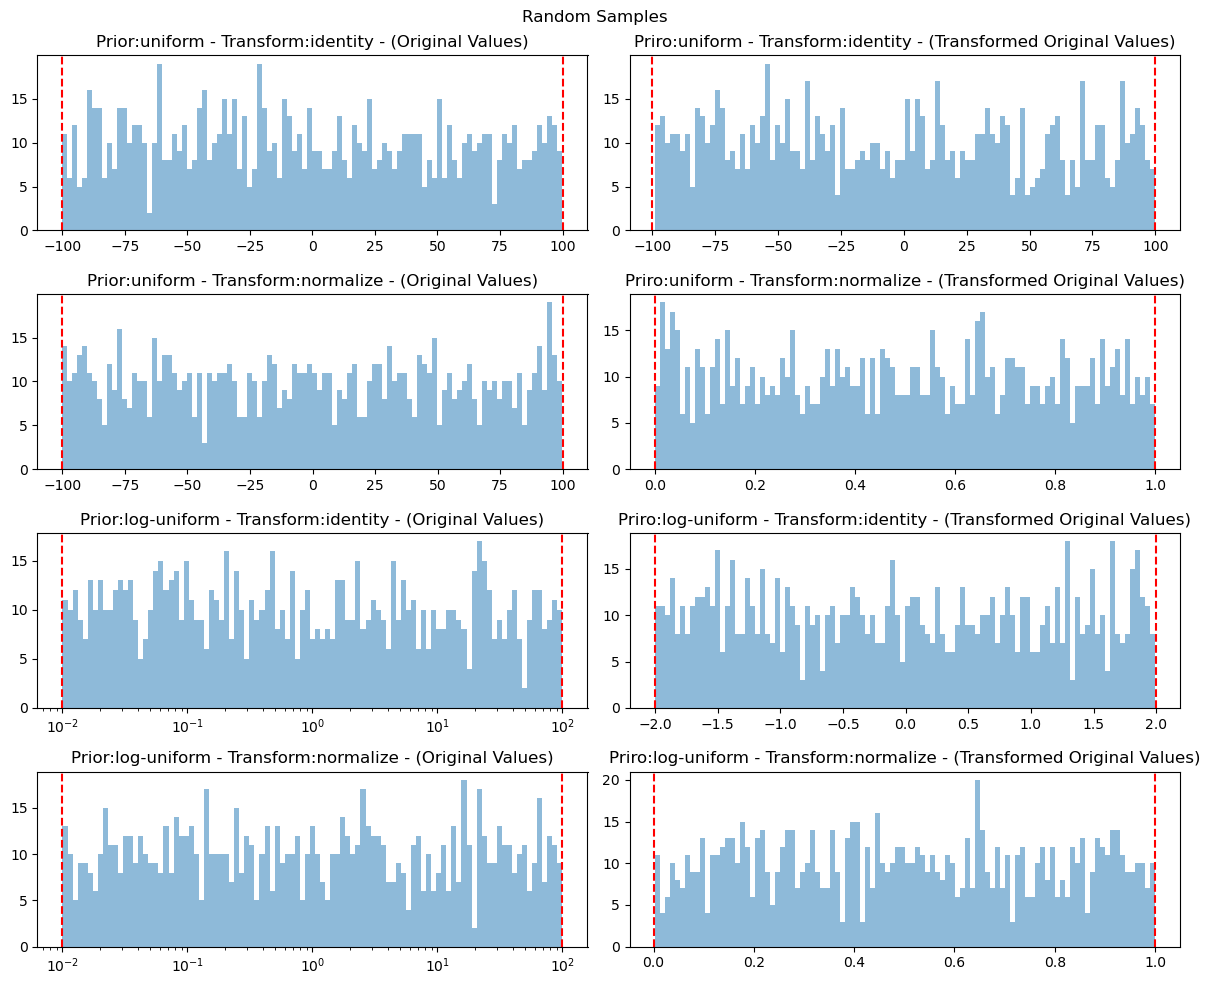

[2025-03-03 14:07:24,580 - INFO - 3093852918.hist_samples]: Histogram Samples
[2025-03-03 14:07:24,581 - INFO - 3093852918.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-03 14:07:24,582 - INFO - 3093852918.hist_samples]: [-1.00e+02 -1.00e+02  1.00e-02  1.00e-02] - Original Samples
[2025-03-03 14:07:24,583 - INFO - 3093852918.hist_samples]: [-1.00e+02  0.00e+00 -2.00e+00  0.00e+00] - Normalized Samples


Grid Samples


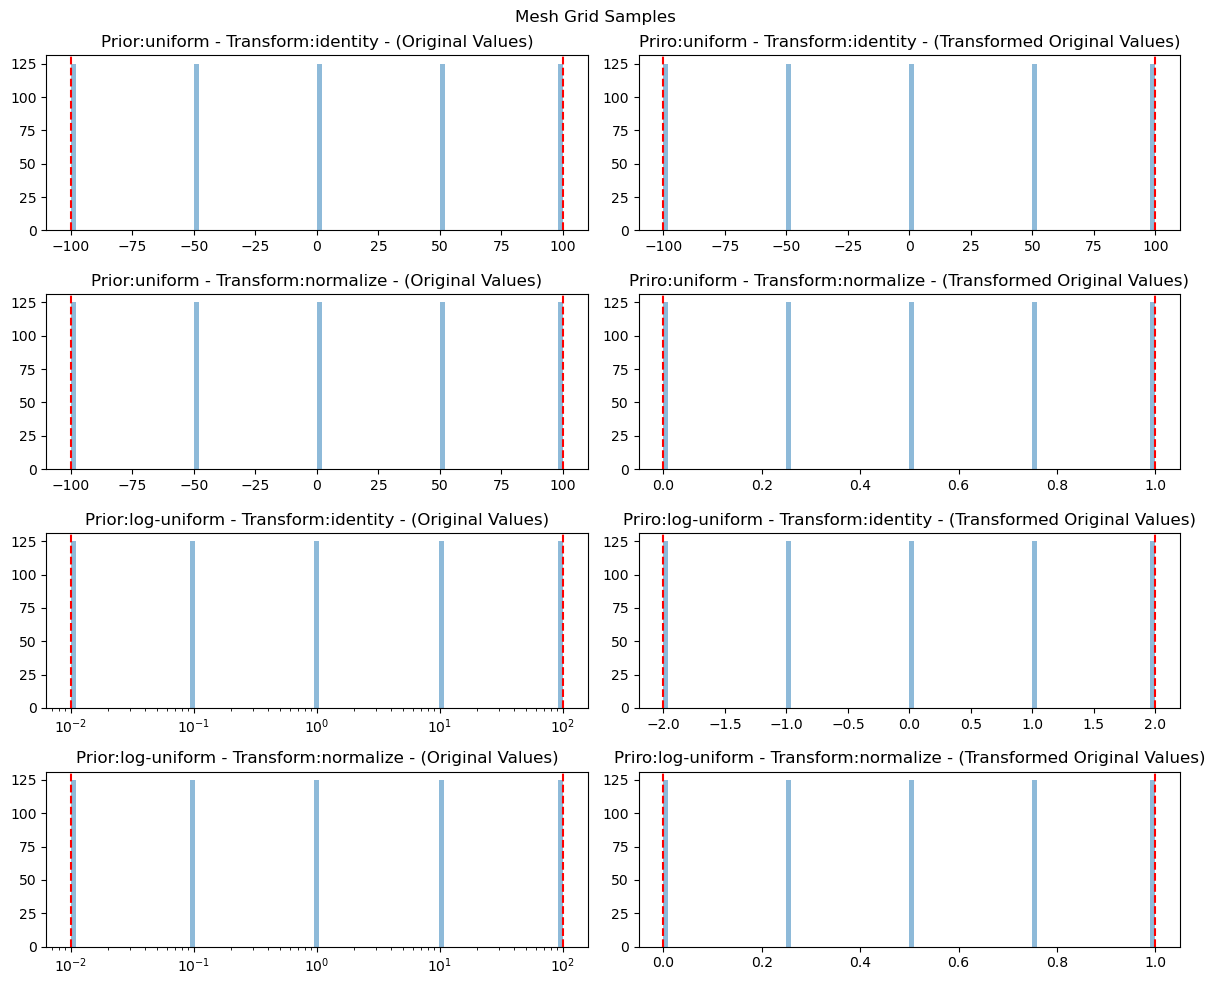

[2025-03-03 14:07:28,405 - INFO - 3093852918.hist_samples]: Histogram Samples
[2025-03-03 14:07:28,406 - INFO - 3093852918.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-03 14:07:28,407 - INFO - 3093852918.hist_samples]: [ 6.70e+00  3.43e+00  1.58e+00  1.52e-02] - Original Samples
[2025-03-03 14:07:28,407 - INFO - 3093852918.hist_samples]: [ 6.83e+01  7.83e-01 -3.04e-01  2.33e-01] - Normalized Samples


LHS Samples


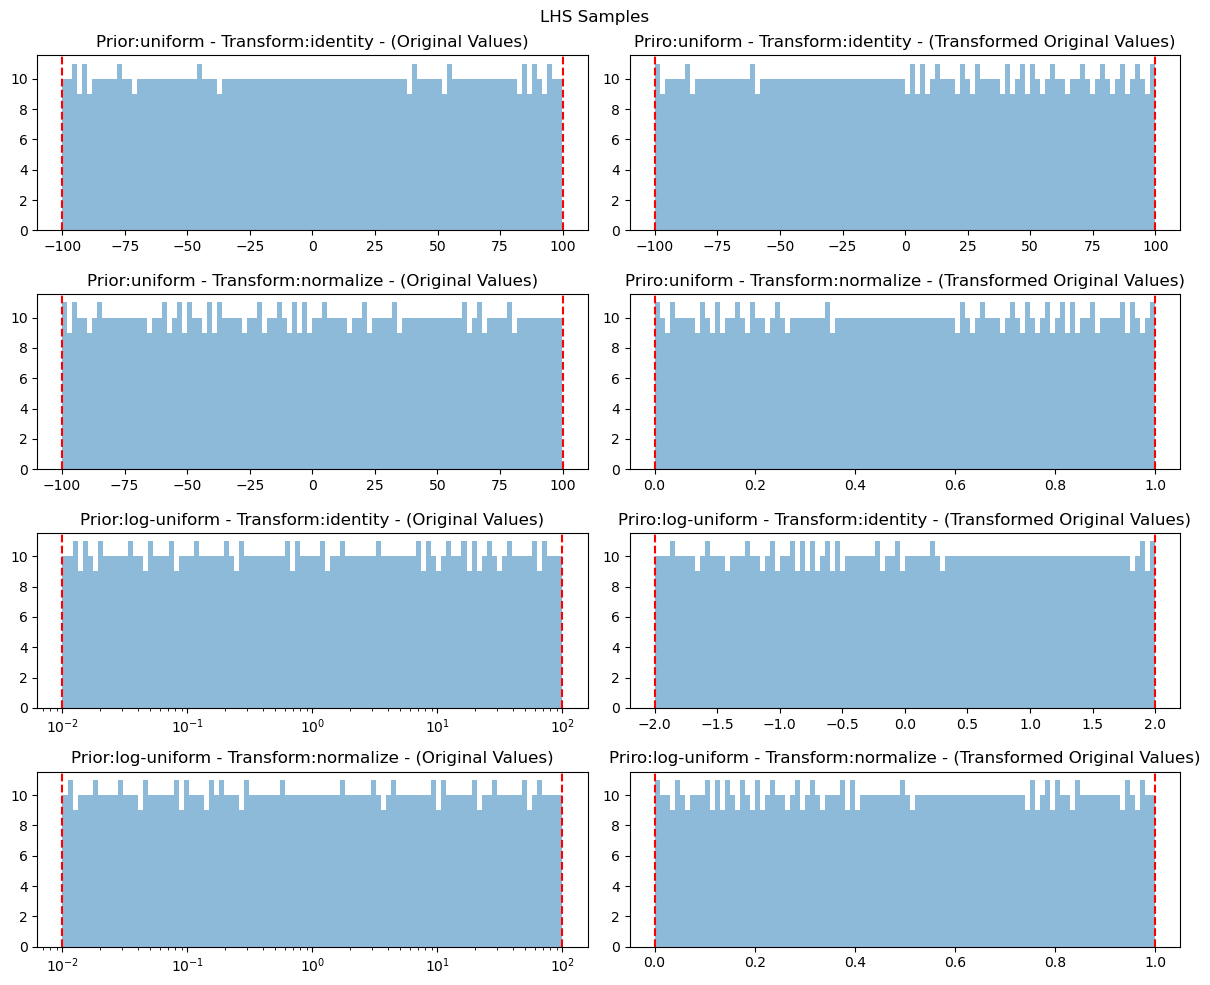

/home/mbo2d/.local/lib/python3.10/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+1000=1000. 
  warnings.warn(
/home/mbo2d/.local/lib/python3.10/site-packages/skopt/sampler/sobol.py:521: UserWarning: The balance properties of Sobol' points require n to be a power of 2. 0 points have been previously generated, then: n=0+1000=1000. 
  warnings.warn(
[2025-03-03 14:07:31,517 - INFO - 3093852918.hist_samples]: Histogram Samples
[2025-03-03 14:07:31,518 - INFO - 3093852918.hist_samples]: Space Names: ['uni-orig', 'uni-norm', 'log-orig', 'log-norm']
[2025-03-03 14:07:31,519 - INFO - 3093852918.hist_samples]: [-1.96e+01  1.27e+01  2.23e+01  1.00e-01] - Original Samples
[2025-03-03 14:07:31,520 - INFO - 3093852918.hist_samples]: [-4.06e+01  7.16e-01 -1.44e+00  9.97e-01] - Normalized Samples


Sobol Samples


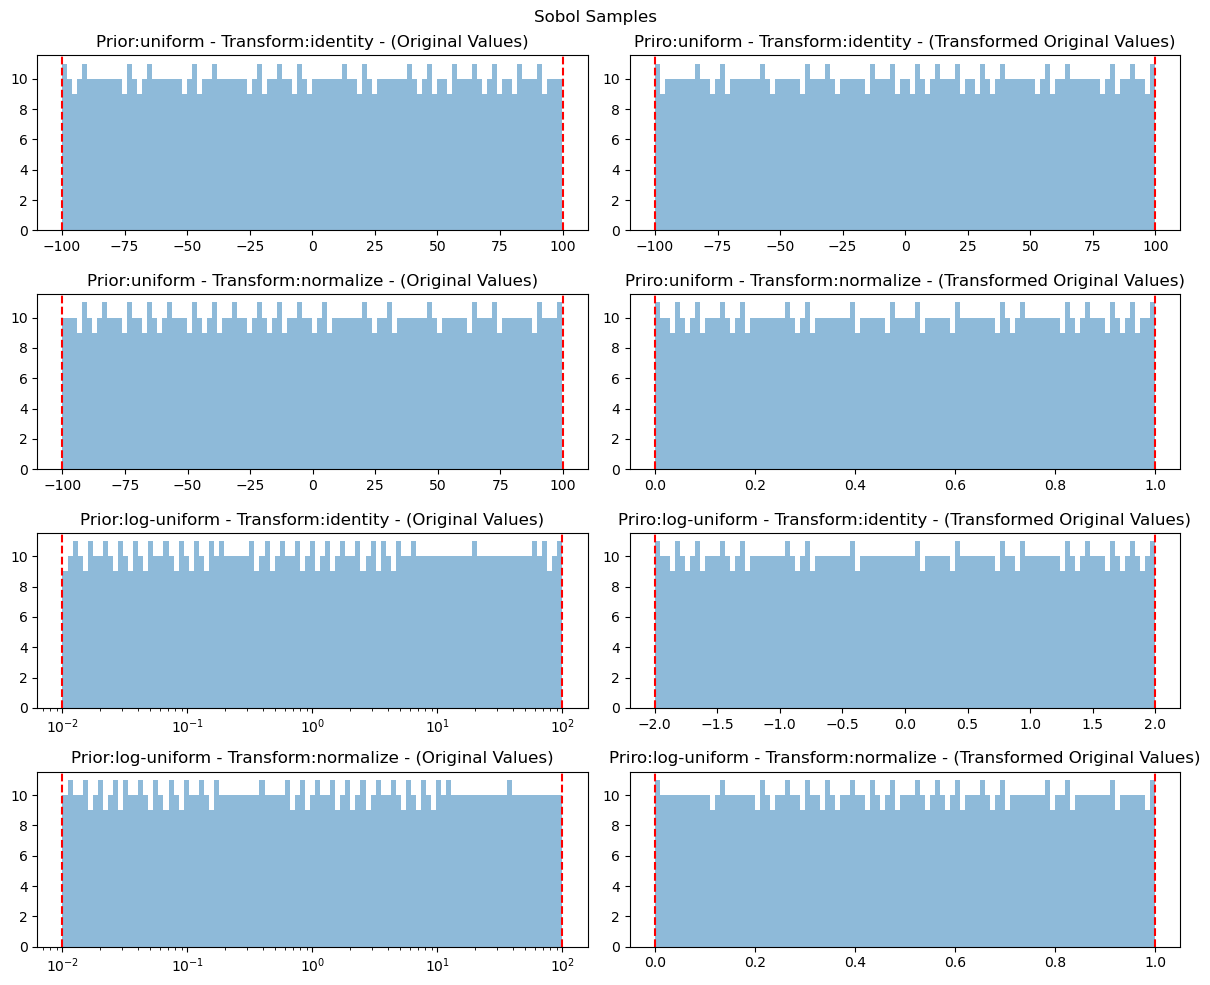

In [35]:
class Space_Manager:
    '''
    Class to manage the space between black-box functions 
    and algorithms that benefit from normalized variables.
    All variables are handled as `Real` for simplicity.
    '''

    def __init__(self, space_info, logger_level=logging.INFO):
        """ Initialize the search space with variable details. """
        self.logger = gu.configure_logging( logger_name = 'Space_Manager', console_log_level = logger_level )
        self.logger.info(f"Initializing Space Manager")
        self.space_info = space_info  # Assume space info is a list of dictionaries
        self.space = self._create_space()
        self.version = 1  # Initialize versioning for space updates
        self.space_record = {} # for storing space details over multiple versions
        self.space_record[self.version] = self.space_info
        self.logger.info(f"Space Manager Initialized")
    # end of __init__

    def get_space(self):
        return self.space_info
    # end of get_space

    def _create_space(self):
        """Creates and initializes the search space with optional transformations."""

        space = []
        for i,var_info in enumerate(self.space_info):

            var_name = var_info['name']  # Required

            # Extract basic attributes
            bounds = var_info.get('bounds', None)  # Required
            prior = var_info.get('prior', 'uniform')  # Default to uniform, used for sampling
            transform = var_info.get('transform', 'identity')  # Default to identity, used for normalization
            meta = var_info.get('meta', {})  # Meta-information (optional)

            # Most types require bounds
            if bounds is None:
                raise ValueError(f"Bounds are required for variable type: {var_name}")

            # Handle Real variable types with transformation
            if transform in ['normalize', 'identity']:
                # If standard transforms (normalize or identity)
                dimension = Real(bounds[0], bounds[1], prior=prior, name=var_name, transform=transform)

                # generate transformed bounds
                dimension.transformed_bounds_ = [dimension.transform(bounds[0]), dimension.transform(bounds[1])]

            else:
                raise ValueError(f"Unsupported transform type: {transform}")

            # Attach meta-information for reference
            if meta:
                dimension.meta = meta  # Store meta info as an attribute
            else:
                dimension.meta = None

            space.append( dimension )

            # Add everything to the space info
            self.space_info[i]['prior'] = prior
            self.space_info[i]['transform'] = transform
            self.space_info[i]['transformed_bounds'] = dimension.transformed_bounds_

        return space
    # end of _create_space

    def update_space(self, space_info):
        """Update the search space with new bounds, variables or transformations."""
        self.space_info = space_info
        self.space = self._create_space()
        self.version += 1
    # end of update_space

    def transform_points(self, points, inverse=False):
        """
        Transforms points from original space to normalized space or vice-versa.
        points: np.ndarray of shape (n_points, n_dims)        
        """

        # If there's a single point, add a dummy axis to make it a batch of one
        if len(points.shape) == 1:
            points = points.reshape(1, -1)
        
        # iterate over columns
        for i in range(points.shape[1]):

            # Apply transformation
            if inverse:
                points[:, i] = self.space[i].inverse_transform(points[:, i])
            else:
                points[:, i] = self.space[i].transform(points[:, i])
            
        if len(points) == 1:
            return points[0]
        else:
            return points
    # end of transform_points

    def get_random_sample( self, n_samples = 3, space='normalized', shuffle=True ):
        """ Get random samples from the search space. """

        samples = np.zeros((n_samples, len(self.space_info)))
        for i, dim in enumerate(self.space):
            samples[:, i] = dim.rvs(n_samples)
        
        if shuffle:
            np.random.permutation(samples)

        if space == 'normalized':
            return self.transform_points(samples)
        else:        
            return samples
    # end of get_random_sample

    def get_mesh_grid_points( self, n_pts_per_dim = 5, space='normalized', shuffle=True ):
        """ Generate mesh grid points for the search space. """

        # Select values along each dimension
        grids = []
        for dim in self.space:
            if dim.prior == 'uniform':
                grids.append(np.linspace(dim.low, dim.high, num=n_pts_per_dim))
            if dim.prior == 'log-uniform':
                grids.append(np.logspace(np.log10(dim.low), np.log10(dim.high), num=n_pts_per_dim))

        # Generate grid points
        grid_points = np.array(np.meshgrid(*grids)).T.reshape(-1, len(self.space))

        if shuffle:
            np.random.permutation(grid_points)

        if space == 'original':
            return grid_points
        else:
            return self.transform_points(grid_points)
    # end of get_mesh_grid_points
           
    def get_lhs_samples( self, n_samples = 10, space='normalized', shuffle=True ):
        """ Get Latin Hypercube samples from the search space. """

        lhs = Lhs(lhs_type="classic", criterion=None)
        samples = np.array( lhs.generate(self.space, n_samples) )
        
        if shuffle:
            np.random.permutation(samples)

        if space == 'normalized':
            return self.transform_points(samples)
        else:
            return samples
    # end of get_lhs_samples

    def get_sobol_samples(self, n_samples=10, space='normalized', shuffle=True):
        """Get Sobol samples from the search space."""

        sampler = Sobol()
        sobol_samples = np.array(sampler.generate(self.space, n_samples))

        if shuffle:
            np.random.permutation(sobol_samples)

        if space == 'normalized':
            return self.transform_points(sobol_samples)
        else:
            return sobol_samples
    # end of get_sobol_samples

    def save_space_details(self, file_path):
        """Save the dimension details to a JSON file."""
        import json

        json.dump(self.space_info, open(file_path, 'w'), indent=2)
    # end of save_space_details
    
# end of SpaceManager class

def hist_samples( o_samples, n_samples, space_info, manager, title='Histograme Samples' ):

    # Create plots with 4 subpltos
    import matplotlib.pyplot as plt
    fig, axs = plt.subplots(len(space_info), 2, figsize=(12, 10))
    # fig, axs = plt.subplots(len(space_info), 4, figsize=(24, 10))
    
    # set main title
    fig.suptitle(title)

    # Turn off debug logging for matplotlib
    plt.rcParams['figure.max_open_warning'] = 0

    # Check if transform works
    ot_samples = manager.transform_points(np.copy(o_samples))
    nt_samples = manager.transform_points(np.copy(n_samples), inverse=True)

    logger.info("Histogram Samples")
    logger.info(f"Space Names: {[var_info['name'] for var_info in space_info]}")
    logger.info(f"{o_samples[0]} - Original Samples")
    # logger.info(f"{ot_samples[0]} - Transformed Original Samples")
    
    logger.info(f"{n_samples[0]} - Normalized Samples")
    # logger.info(f"{nt_samples[0]} - Transformed Normalized Samples")

    logger.setLevel(logging.INFO)

    for i, var_info in enumerate(space_info):
        var_name = var_info['name']
        # print(f"\nVariable: {var_name}")
        # Add to first subplot
        if var_info['prior'] == 'log-uniform':
            # Bin with log scaling
            axs[i, 0].set_xscale('log')
            axs[i, 0].hist(o_samples[:, i], bins=np.logspace(np.log10(var_info['bounds'][0]), np.log10(var_info['bounds'][1]), 100), alpha=0.5, label='Original')
        
        else:
            axs[i, 0].hist(o_samples[:, i], bins=100, alpha=0.5, label='Original')

        # axs[i, 2].hist(ot_samples[:, i], bins=100, alpha=0.5, label='Transformed Original')
        # axs[i, 3].hist(nt_samples[:, i], bins=100, alpha=0.5, label='Transformed Normalized')

        axs[i, 1].hist(n_samples[:, i], bins=100, alpha=0.5, label='Normalized')
        
        axs[i, 0].set_title(f"Prior:{var_info['prior']} - Transform:{var_info['transform']} - (Original Values)")
        axs[i, 1].set_title(f"Priro:{var_info['prior']} - Transform:{var_info['transform']} - (Transformed Original Values)")

        # Add bounds to the plot
        axs[i, 0].axvline(var_info['bounds'][0], color='r', linestyle='--')
        axs[i, 0].axvline(var_info['bounds'][1], color='r', linestyle='--')

        try:
            axs[i, 1].axvline(manager.space[i].transformed_bounds_[0], color='r', linestyle='--')
            axs[i, 1].axvline(manager.space[i].transformed_bounds_[1], color='r', linestyle='--')
        except:
            pass
    
    # logger.setLevel(logging.DEBUG)
    
    # tight layout
    plt.tight_layout()
    plt.show()


def test_space_manager():
    logger.info(f"Testing Space Manager")

    logger.setLevel(logging.INFO)

    space_transform_test = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-100, 100], 'prior':'uniform', 'transform':'identity'  }, # Working
        {'name':'uni-norm', 'type': 'float', 'bounds': [-100, 100], 'prior':'uniform', 'transform':'normalize' }, # Working
        {'name':'log-orig', 'type': 'float', 'bounds': [1e-2, 100], 'prior':'log-uniform', 'transform':'identity' }, # Working
        {'name':'log-norm', 'type': 'float', 'bounds': [1e-2, 100], 'prior':'log-uniform', 'transform':'normalize' }, # Working
    ]
    
    print("\nTesting Space Manager with Input Space:")
    for var_info in space_transform_test:
        print(var_info)
    # gu.pp(space_transform_test)
    print('')

    manager = SpaceManager(space_transform_test)

    manager.save_space_details('test_space_details.json')

    n = 1000
    o_samples = manager.get_random_sample(n, space='original') # original samples
    n_samples = manager.get_random_sample(n, space='normalized') # normalized samples
    
    print("Random Samples")
    hist_samples( o_samples, n_samples, space_transform_test, manager, title='Random Samples' )

    if True:

        # Do the same with gridsearch
        o_samples = manager.get_mesh_grid_points(5, space='original') # original samples
        n_samples = manager.get_mesh_grid_points(5, space='normalized') # normalized samples
        print("Grid Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='Mesh Grid Samples' )

        # Do the same with LHS
        o_samples = manager.get_lhs_samples(n, space='original') # original samples
        n_samples = manager.get_lhs_samples(n, space='normalized') # normalized samples
        print("LHS Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='LHS Samples' )

        # Do the same with Sobol
        o_samples = manager.get_sobol_samples(n, space='original') # original samples
        n_samples = manager.get_sobol_samples(n, space='normalized') # normalized samples
        print("Sobol Samples")
        hist_samples( o_samples, n_samples, space_transform_test, manager, title='Sobol Samples' )

if buildEnv:
    # Set numpy precision print with arrays as sci format with 3 decimals w space for sign
    np.set_printoptions(precision=3, suppress=True, formatter={'all': lambda x: f'{x: 0.2e}'})
    test_space_manager()

[2025-03-03 14:08:04,676 - INFO - 795737573.<module>]: My Current log level is 'DEBUG'
[2025-03-03 14:08:04,677 - INFO - 795737573.<module>]: Function Logger is at 'INFO'
[2025-03-03 14:08:04,678 - INFO - 795737573.<module>]: Having test module call print log function
[2025-03-03 14:08:04,683 - INFO - parallel_queue_manager._set_local_mode]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[2025-03-03 14:08:04,746 - INFO - parallel_queue_manager.__del__]: Queue Manager Deleted


Creating a new logger for testing the test function
You should see function calls
test print: 2test print: 3test print: 4




[2025-03-03 14:08:05,342 - ERROR - 795737573.testing_logger]: Error: 2
[2025-03-03 14:08:05,343 - ERROR - 795737573.testing_logger]: Error: 3
[2025-03-03 14:08:05,344 - ERROR - 795737573.testing_logger]: Error: 4
[2025-03-03 14:08:05,345 - CRITICAL - 795737573.testing_logger]: Critical: 2
[2025-03-03 14:08:05,345 - CRITICAL - 795737573.testing_logger]: Critical: 3
[2025-03-03 14:08:05,346 - CRITICAL - 795737573.testing_logger]: Critical: 4
[2025-03-03 14:08:05,347 - DEBUG - 795737573.testing_logger]: Std Logger Debug: 2
[2025-03-03 14:08:05,347 - DEBUG - 795737573.testing_logger]: Std Logger Debug: 3
[2025-03-03 14:08:05,348 - DEBUG - 795737573.testing_logger]: Std Logger Debug: 4
[2025-03-03 14:08:05,351 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 3/3 - Queue Complete
[2025-03-03 14:08:05,354 - INFO - 795737573.<module>]: Results: [4, 6, 8]
[2025-03-03 14:08:05,355 - INFO - 795737573.testing_logger]: Info: 5
[2025-03-03 14:08:

test print: 5
test print: [-1.44e+00]test print: [ 1.37e+00]test print: [-1.59e+00]test print: [ 1.07e+00]





[2025-03-03 14:08:05,929 - ERROR - 795737573.testing_logger]: Error: [-1.59e+00]
[2025-03-03 14:08:05,929 - ERROR - 795737573.testing_logger]: Error: [ 1.07e+00]
[2025-03-03 14:08:05,929 - ERROR - 795737573.testing_logger]: Error: [ 1.37e+00]
[2025-03-03 14:08:05,929 - ERROR - 795737573.testing_logger]: Error: [-1.44e+00]
[2025-03-03 14:08:05,931 - CRITICAL - 795737573.testing_logger]: Critical: [-1.59e+00]
[2025-03-03 14:08:05,931 - CRITICAL - 795737573.testing_logger]: Critical: [ 1.07e+00]
[2025-03-03 14:08:05,932 - CRITICAL - 795737573.testing_logger]: Critical: [ 1.37e+00]
[2025-03-03 14:08:05,933 - DEBUG - 795737573.testing_logger]: Std Logger Debug: [-1.59e+00]
[2025-03-03 14:08:05,932 - CRITICAL - 795737573.testing_logger]: Critical: [-1.44e+00]
[2025-03-03 14:08:05,933 - DEBUG - 795737573.testing_logger]: Std Logger Debug: [ 1.07e+00]
[2025-03-03 14:08:05,934 - DEBUG - 795737573.testing_logger]: Std Logger Debug: [ 1.37e+00]
[2025-03-03 14:08:05,938 - INFO - parallel_queue_man


Testing Input Space:
{'name': 'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'identity'}
{'name': 'log-orig', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'identity'}
{'name': 'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'normalize'}
{'name': 'log-norm', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'normalize'}

Test Function: Sum of Squares (sum(x^2))


[2025-03-03 14:08:06,854 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 1000/1000 - Queue Complete
[2025-03-03 14:08:06,861 - DEBUG - 1358050660.evaluate_function_normalized]:  y.shape: (1000, 1) -  y[0]: [ 1.09e+01]
[2025-03-03 14:08:06,863 - DEBUG - 1358050660.evaluate_function_normalized]: ny.shape: (1000, 1) - ny[0] [ 2.48e+00]
[2025-03-03 14:08:07,386 - DEBUG - 1358050660.scatter_input]: Scatter Plot: x: (1000, 4) y: (1000, 1)
[2025-03-03 14:08:07,389 - DEBUG - 1358050660.scatter_input]: Presorted Y: (1000, 1)
[2025-03-03 14:08:07,390 - DEBUG - 1358050660.scatter_input]: PreCol Y: (1000, 1)
[2025-03-03 14:08:07,391 - DEBUG - 1358050660.scatter_input]: Scatter Plot: x: (1000,) y: (1000,)
[2025-03-03 14:08:07,392 - DEBUG - 1358050660.scatter_input]: NaNs in y: 0
[2025-03-03 14:08:07,394 - DEBUG - 1358050660.scatter_input]: Infs in y: 0
[2025-03-03 14:08:07,448 - DEBUG - 1358050660.scatter_input]: Scatter Plot: x: (1000, 4) y: (


Running 10000 samples as a stress test


[2025-03-03 14:08:09,509 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [=                   ] 673/10000
[2025-03-03 14:08:10,516 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [=====               ] 2740/10000
[2025-03-03 14:08:11,522 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [=========           ] 4808/10000
[2025-03-03 14:08:12,527 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [==============      ] 7222/10000
[2025-03-03 14:08:13,462 - INFO - parallel_queue_manager._run_local_processes]: Local Manager: Progress: [====================] 10000/10000 - Queue Complete
[2025-03-03 14:08:13,494 - DEBUG - 1358050660.evaluate_function_normalized]:  y.shape: (10000, 1) -  y[0]: [ 1.43e+01]
[2025-03-03 14:08:13,496 - DEBUG - 1358050660.evaluate_function_normalized]: ny.shape: (10000, 1) - ny[0] [ 6.52e-02]
[2025-03-03 14:08:13,499 - INFO - 1358050660.__del_

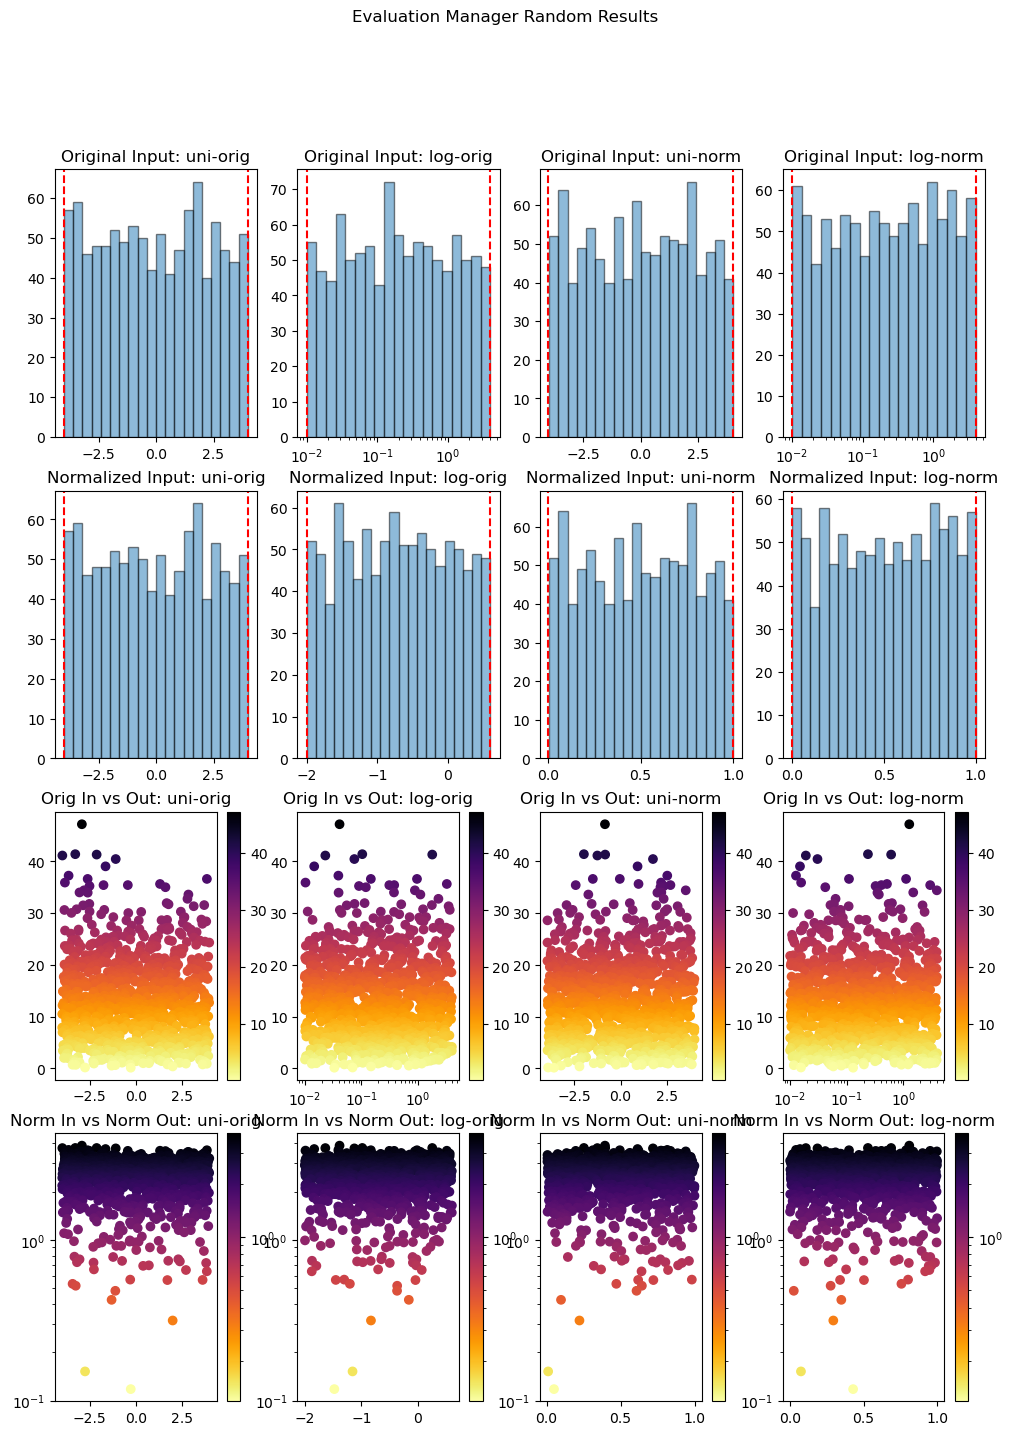

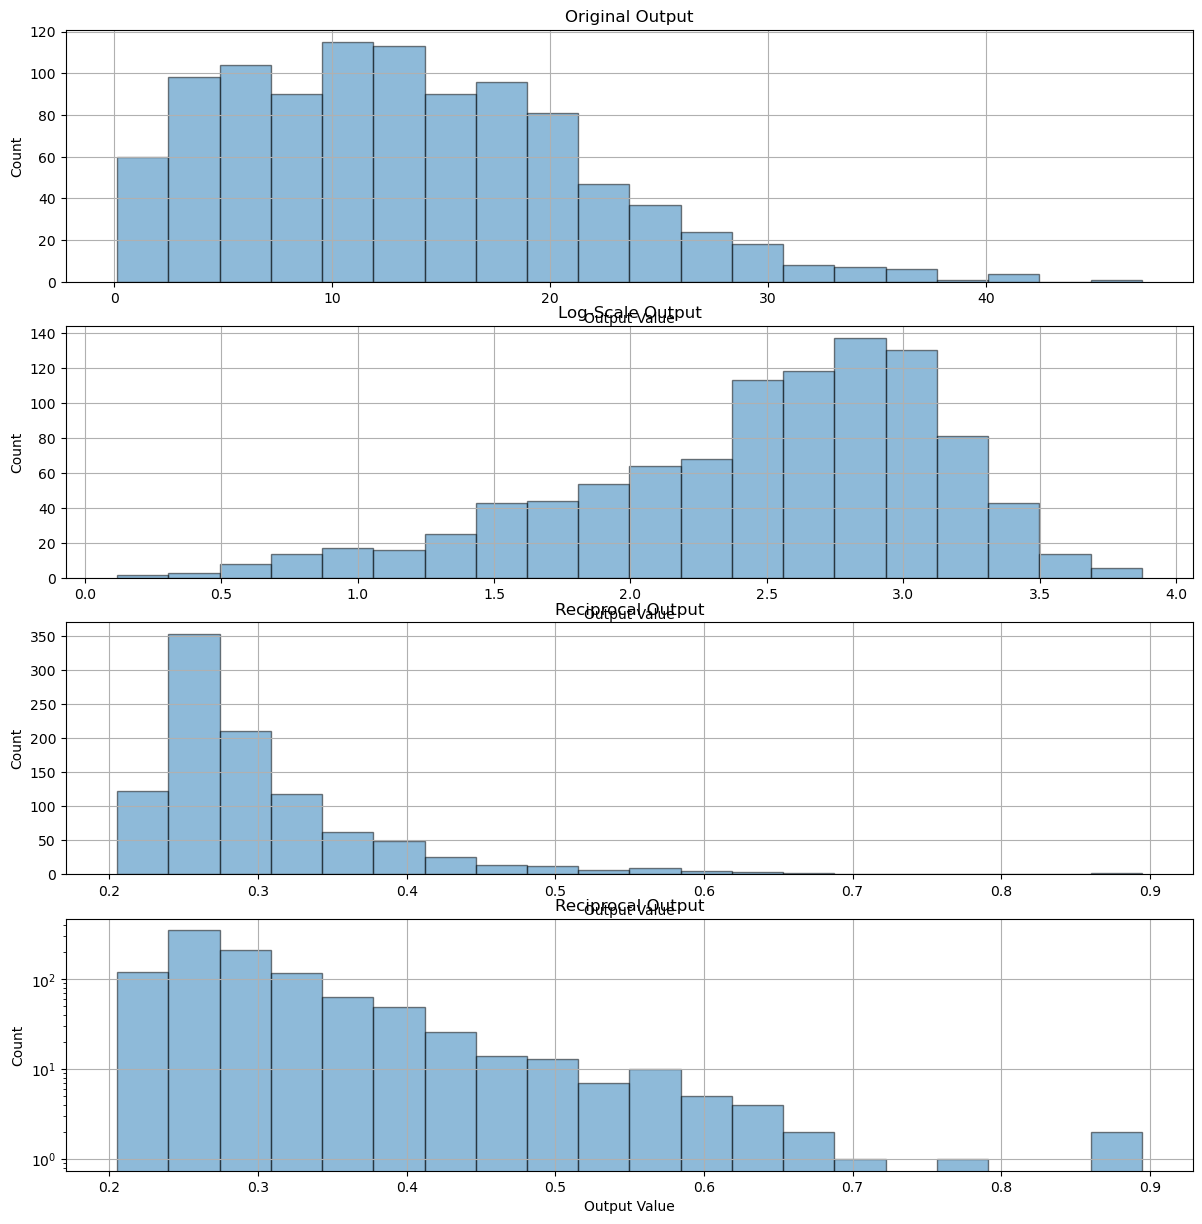

In [37]:
class Execution_Manager:
    """
    Class to manage the execution of black-box functions in parallel.
    Interfaces with the space manager to handle normalized dimensions.
    Also normalizes the final scores if requested.
    Feeds noramlized inputs and ouputs to higher-level optimization algorithms.
    NOTE: This is intended for computationlly expensive functions.
    """

    def __init__( self, space_manager, black_box_function, normalize_output='original',
                 save_results=True, num_outputs=1, exec_log_level=logging.INFO,
                 func_logger = None, func_log_level = logging.WARNING,
                 ):
        
        """Initialize the execution manager with the function to evaluate."""
        self.logger = gu.configure_logging( logger_name='execution_manager', log_level=exec_log_level )
        self.logger.info(f"Initializing Execution Manager")

        self.save_results = save_results
        self.space_manager = space_manager
        self.n_dims = len(space_manager.space_info)
        self.n_out = num_outputs
        self.x = np.zeros((0, self.n_dims)) # Original Inputs
        self.y = np.zeros((0, self.n_out)) # Original Outputs
        self.xn = np.zeros((0, self.n_dims)) # Normalized Inputs
        self.yn = np.zeros((0, self.n_out)) # Normalized Outputs
        self.bad_x = np.zeros((0, self.n_dims)) # Bad Inputs

        # Generate output normalizer function
        self.gen_output_normalizer(normalize_output)

        # Setup Execution Environment for black box function
        self.function = black_box_function
        self.func_logger = func_logger if func_logger is not None else logging.getLogger('')  # Assume function uses root logger if not provided
        self.func_log_level = func_log_level
        self.comm = MPI.COMM_WORLD
        self.rank = self.comm.Get_rank()
        self.size = self.comm.Get_size()

        # Setup Parallel workers to be on standby to process black box function evaluations
        if self.rank != 0:
            self.logger.info(f"Execution Worker on Standby")
            self.queue_manager = qm.Queue_Worker(self.function)
            return
        
        # Else you're the manager. Continue with initialization
        self.queue_manager = qm.Queue_Manager(self.function)

        # Else, you're a manager. Continue with initialization
        self.logger.info(f"Execution Manager Initialized")
        
    # end of __init__

    def __del__(self):
        if self.rank == 0:
            self.queue_manager.terminate_workers()
        self.logger.info(f"Execution Manager Terminated")
    # end of __del__

    def set_function_log_level( self, log_level ):
        """Set the log level for the function logger."""
        self.func_logger.setLevel(log_level)
    # end of set_function_log_level

    def evaluate_function(self, x, space = 'normalized', save_results=None):
        """Evaluate the black-box function for a given list."""
        self.logger.info(f"Evaluating Function: Inputs: {len(x)}")
        self.logger.debug(f"x - {len(x)}: {x[0]}")

        if save_results is None:
            save_results = self.save_results
        
        # Save previous func logger level
        prev_log_level = self.func_logger.level

        # set to new level
        self.func_logger.setLevel(self.func_log_level)

        if space == 'normalized':
            results = self.evaluate_function_normalized(x, save_results)
        elif space == 'original':
            results =  self.evaluate_function_from_original(x, save_results)
               
        # Return to previous level
        self.func_logger.setLevel(prev_log_level)

        return results
    # end of evaluate_function

    def evaluate_function_normalized(self, nx, save_results=None):
        """Evaluate the black-box function for a given list."""

        if save_results is None:
            save_results = self.save_results

        # If x is list, convert to numpy array
        if isinstance(nx, list):
            nx = np.array(nx)

        self.logger.info("Starting Normalized Evaluation of Function")
        self.logger.debug(f"nx.shape{nx.shape} - nx[0]: {nx[0]}")

        # Check if ranges are appropriate
        for i, dim in enumerate(self.space_manager.space):
            min_value = np.amin( nx[:, i] )
            max_value = np.amax( nx[:, i] )
            if not ( (dim.transformed_bounds_[0] <= min_value ) and ( max_value <= dim.transformed_bounds_[1]) ):
                raise ValueError(f"Input Column {i} is out of bounds: [{min_value:.2e}, {max_value:.2e}] not in [min, max] [{dim.low}, {dim.high}]")
        
        # Inverse transform the normalized inputs to orginal space
        x = np.copy(nx)
        x = self.space_manager.transform_points(np.copy(nx), inverse=True)
        self.logger.debug(f" x.shape{nx.shape} -  x[0]: {x[0]}")
        
        # Add list to the queue and evaluate
        y_raw = self.queue_manager.evaluate_tasks(x)

        # Loop backwards through returns and remove any None values, as well as corresponding x values
        popped_count = 0
        for i in range( len(y_raw) - 1, -1, -1):
            
            # Check if exception value was given
            if isinstance(y_raw[i], Exception):

                # print exception before removing
                self.logger.warning(f"Exception Returned: '{y_raw[i]}'")
                self.bad_x = np.vstack([self.bad_x, x[i]])
                x = np.delete(x, i, axis=0)
                nx = np.delete(nx, i, axis=0)
                y_raw.pop(i)
                popped_count += 1

            elif isinstance(y_raw[i], type(None)):
                self.bad_x = np.vstack([self.bad_x, x[i]])
                x = np.delete(x, i, axis=0)
                nx = np.delete(nx, i, axis=0)
                y_raw.pop(i)
                popped_count += 1

        if popped_count > 0:
            self.logger.warning(f"Removed {popped_count} of {len(x)+popped_count} inputs due to None/Null")
        
        # Check if all evaluations failed
        if len(x) == 0:
            self.logger.error(f"All Executions failed.  Raising error")
            raise ValueError("All Functions Evaluations Failed")
        
        y = np.array( y_raw )

        # Make sure y is 2D
        if len(y.shape) == 1:
            y = y.reshape(-1, self.n_out)

        self.logger.debug(f" y.shape: {y.shape} -  y[0]: {y[0]}")
        ny = self.output_normalizer(y)

        self.logger.debug(f"ny.shape: {ny.shape} - ny[0] {ny[0]}")

        # add retsults to the results array
        if save_results:
            self.x = np.vstack([self.x, x])
            self.y = np.vstack([self.y, y])
            self.xn = np.vstack([self.xn, nx])
            self.yn = np.vstack([self.yn, ny])

        return ny
    # end of evaluate_function

    def evaluate_function_from_original(self, x, save_results=None):
        """Evaluate the black-box function for a given list."""

        # If save_results is None, use the default
        if save_results is None:
            save_results = self.save_results

        # If tx is list, convert to numpy array
        if isinstance(x, list):
            x = np.array(x)
        self.logger.debug(f"x - {x.shape}: {x[0]}")

        # Add list to the queue and evaluate
        y_raw = self.queue_manager.evaluate_tasks(x)

        # Loop backwards through returns and remove any None values, as well as corresponding x values
        for i in range( len(y_raw) - 1, -1, -1):
            if y_raw[i] is None:
                x = np.delete(x, i, axis=0)
                y_raw.pop(i)
        
        y = np.array( y_raw )
        self.logger.debug(f"y - {y.shape}: {y[0]}")

        if save_results:

            # If 1D, add a dummy axis
            if len(x.shape) == 1:
                x = x.reshape(-1, self.n_dims)
            if len(y.shape) == 1:
                y = y.reshape(-1, self.n_out) 

            self.logger.debug(f"Saving Results: x: {x.shape} y: {y.shape}")
            self.logger.debug(f"Saving to x: {self.x.shape} y: {self.y.shape}")
            self.x = np.vstack([self.x, x])    
            self.y = np.vstack([self.y, y])
            self.logger.debug(f"Stacked Results: x: {self.x.shape} y: {self.y.shape}")

        return y
    # end of evaluate_function

    def get_results( self, last_n = -1, space='normalized' ):
        """Get the results from the execution manager."""

        if space == 'original':
            return( self.x.copy(), self.y.copy() )

        elif space == 'normalized':
            return( self.xn.copy(), self.yn.copy() )
    # end of get_results

    def gen_output_normalizer(self, normalize_output='original'):
        """Create the output normalizer function."""

        # Create output normalization function
        if normalize_output == 'original':
            self.output_normalizer = lambda x: x

        elif normalize_output == 'negate':
            self.output_normalizer = lambda x: -1.0 * x

        elif normalize_output == 'log':
            self.output_normalizer = lambda x: np.log1p(x)

        elif normalize_output == 'reciprocal':
            self.output_normalizer = lambda x: 1.0 / (1.0 + x)

        else:
            self.logger.error(f"Unsupported output normalization: {normalize_output}")
            self.logger.error(f"Accepted values: original, negate, log, reciprocal")
            raise ValueError(f"Unsupported output normalization: {normalize_output}")
    # end of gen_output_normalizer

    def new_output_normalizer(self, new_norm):
        """Change the output normalizer function."""
        self.gen_output_normalizer(new_norm)
        for c in range(self.yn.shape[1]):
            self.yn[:, c] = self.output_normalizer(self.yn[:, c])

    def clear_results(self):
        """Clear the results stored in the manager."""
        self.x = np.zeros((0, self.n_dims))
        self.y = np.zeros((0, self.n_out))
        self.xn = np.zeros((0, self.n_dims))
        self.yn = np.zeros((0, self.n_out))

    def hist_input( self, dim_index = None, dim_name = None, space='original',
                         title=None, external_ax = None, fig_size = None, external_results = None, 
                         max_bins = 20,
                         ):
        

        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (12, 10) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size) 
        
        else:
            ax = external_ax
        
        # Get the results
        x, y = self.get_results(space=space) if external_results is None else external_results
        
        if dim_index is None:
            self.logger.error(f"Dimension Name: {dim_name} not found in space info")
            self.logger.error(f"Available Dimension Names: {all_names}")
            raise ValueError("dim_index must be provided")
    
        # Filter to single dimension
        x = x[:, dim_index]
        dim_info = self.space_manager.space_info[dim_index]

        # Get # of bins based on unique values
        n_bins = len(np.unique(x)) if len(np.unique(x)) < max_bins else max_bins
        
        # Use logarithmic bins if the dimension is log-uniform
        if dim_info['prior'] == 'log-uniform' and space == 'original':
            ax.hist(x, bins=np.logspace(np.log10(dim_info['bounds'][0]), np.log10(dim_info['bounds'][1]), n_bins), alpha=0.5, edgecolor='black')
            ax.set_xscale('log')
        else:
            ax.hist(x, bins=n_bins, alpha=0.5, edgecolor='black')
        
        # Set title
        if title is None:
            title = f"Histogram of {dim_info['name']} ({space})"

        # Add bounds
        
        # Add bounds to the plot
        if space == 'original':
            ax.axvline(dim_info['bounds'][0], color='r', linestyle='--')
            ax.axvline(dim_info['bounds'][1], color='r', linestyle='--')

        else:
            ax.axvline(self.space_manager.space[dim_index].transformed_bounds_[0], color='r', linestyle='--')
            ax.axvline(self.space_manager.space[dim_index].transformed_bounds_[1], color='r', linestyle='--')
        ax.set_title(title)
        
    def hist_output(self, space='original', title=None, external_ax = None, max_bins = 20, y_idx = 0,
                     fig_size = None, external_results = None, log_x = False, log_y=False, reverse_color=False):
        
        # Histogram output values

        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (12, 10) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size)
        
        else:
            ax = external_ax

        # Get the results
        x, y = self.get_results(space=space) if external_results is None else external_results

        # Get the output values, final column
        y = y[:, y_idx]

        # Get # of bins based on unique values or length or default
        n_bins = len(np.unique(y)) if len(np.unique(y)) < max_bins else max_bins

        # Use logarithmic bins if log scale requested
        if log_x:
            ax.hist(y, bins=np.logspace(np.log10(np.min(y)), np.log10(np.max(y)), n_bins), alpha=0.5, edgecolor='black')
            ax.set_xscale('log')
        else:
            ax.hist(y, bins=n_bins, alpha=0.5, edgecolor='black')
        
        if log_y:
            ax.set_yscale('log')
        
        # Set title
        if title is None:
            title = f"{space} Output Values {y_idx}"
        
        ax.set_title(title)
        ax.set_xlabel('Output Value')
        ax.set_ylabel('Count')
        ax.grid(True)

    def scatter_input( self, dim_index = None, dim_name = None, space='original', title = None, y_idx = 0,
                                   external_ax = None, fig_size = None, external_results = None, output_log_scale = False, reverse_color=False):
        
        """Scatter plot of input dimension vs output values."""
        # If external axis is None, create a new figure
        if external_ax is None:
            fig_size = (6, 6) if fig_size is None else fig_size
            fig, ax = plt.subplots(figsize=fig_size)
        else:
            ax = external_ax

        # Get the results
        x,y = self.get_results(space=space) if external_results is None else external_results
        self.logger.debug(f"Scatter Plot: x: {x.shape} y: {y.shape}")

        # Reverse sort and filter to desired output
        sorted_idx = np.argsort(y[:, y_idx])
        self.logger.debug(f"Presorted Y: {y.shape}")
        y = y[sorted_idx[::-1]]
        self.logger.debug(f"PreCol Y: {y.shape}")
        y = y[:, y_idx]

        # Filter to desired dimension
        x = x[:, dim_index]

        self.logger.debug(f"Scatter Plot: x: {x.shape} y: {y.shape}")
        self.logger.debug(f"NaNs in y: {np.isnan(y).sum()}")
        self.logger.debug(f"Infs in y: { np.isinf(y).sum()}")

        # Scatter plot
        color = 'inferno_r' if reverse_color else 'inferno'
        if output_log_scale:
            sc = ax.scatter(x, y, c=y, norm=mcolors.LogNorm(vmin=np.min(y), vmax=np.max(y)), cmap=color, alpha=1)
        else:
            sc = ax.scatter(x, y, c=y, cmap=color, alpha=1)

        # add color barimport numpy as np


        cbar = plt.colorbar(sc)

        # Set x scale
        if self.space_manager.space_info[dim_index]['prior'] == 'log-uniform' and space == 'original':
            ax.set_xscale('log')

        # Log scale y if requested
        if output_log_scale:
            ax.set_yscale('log')
        
        # Set title
        if title is None:
            title = f"{space} {self.space_manager.space_info[dim_index]['name']} vs Output {plot_y_idx}"
        ax.set_title(title)
    # end of scatter_input_with_results

def test_evaluation_manager():

    logger.info(f"Testing Evaluation Manager")

    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  }, # Working
        {'name':'log-orig', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'identity' }, # Working
        {'name':'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'normalize' }, # Working
        {'name':'log-norm', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'normalize' }, # Working
    ]

    print("\nTesting Input Space:")
    for var_info in test_space:
        print(var_info)
    space_manager = SpaceManager(test_space)

    test_function = lambda x: np.sum(x**2)
    print("\nTest Function: Sum of Squares (sum(x^2))")
    
    exec_manager = ExecutionManager(space_manager, black_box_function=test_function, normalize_output='log')

    # Validate the evaluation manager inputs/outputs are working correctly
    n = 1000
    n_samples = space_manager.get_random_sample(n,) # Remeber, default is normalized
    n_outputs = exec_manager.evaluate_function(n_samples)

    # Create subplot for each dimension
    fig, axs = plt.subplots(4, 4, figsize=(12, 16))

    # Set main title
    fig.suptitle("Evaluation Manager Random Results")

    # Histogram of inputs and outputs
    for i, dim_info in enumerate(space_manager.space_info):
        # inputs
        exec_manager.hist_input(dim_index=i, space='original', external_ax=axs[0,i], title=f"Original Input: {dim_info['name']}")
        exec_manager.hist_input(dim_index=i, space='normalized', external_ax=axs[1,i], title=f"Normalized Input: {dim_info['name']}",)
        exec_manager.scatter_input(dim_index=i, space='original', external_ax=axs[2,i], title=f"Orig In vs Out: {dim_info['name']}", reverse_color=True)
        exec_manager.scatter_input(dim_index=i, space='normalized', external_ax=axs[3,i], title=f"Norm In vs Norm Out: {dim_info['name']}", output_log_scale=True, reverse_color=True)


    # Create subplot for each dimension
    # plt.clf()
    fig, axs = plt.subplots(4, figsize=(12, 12))
    plt.tight_layout()

    # Histogram of outputs
    exec_manager.hist_output(space='original', external_ax=axs[0,], title="Original Output", reverse_color=True)
    exec_manager.hist_output(space='normalized', external_ax=axs[1,], title="Log-Scale Output", reverse_color=True)

    # New Normalized Output
    exec_manager.new_output_normalizer('reciprocal')  # Reciprocal normalization (bounded between 0 and 1)
    exec_manager.hist_output(space='normalized', external_ax=axs[2], title="Reciprocal Output", reverse_color=False)
    exec_manager.hist_output(space='normalized', external_ax=axs[3], title="Reciprocal Output", reverse_color=False, log_y=True)

    if True:
        # Let's stress test the evaluation manager, verify parallelism is working
        n = 10000
        print("\nRunning 10000 samples as a stress test")
        n_samples = space_manager.get_random_sample(n, space='normalized') # normalized samples
        n_outputs = exec_manager.evaluate_function(n_samples)

if buildEnv:
    reload(qm)

    # Set current logger
    logger.setLevel(logging.DEBUG)

    # Create test logger
    test_logger = gu.configure_logging( logger_name='test_logger', log_level=logging.INFO)

    # Test having multiple loggers
    def testing_logger( x ):
        print(f"test print: {x}")
        test_logger.debug(f"Debug: {x}")
        test_logger.info(f"Info: {x}")
        test_logger.warning(f"Warning: {x}")
        test_logger.error(f"Error: {x}")
        test_logger.critical(f"Critical: {x}")
        logger.debug(f"Std Logger Debug: {x}")
        # raise TypeError("Testing Error")
        return 2*x
    
    logger.info(f"My Current log level is '{logging.getLevelName(logger.level)}'")
    logger.info(f"Function Logger is at '{logging.getLevelName(test_logger.level)}'")
    logger.info(f"Having test module call print log function")
    # testing_logger(1)

    # Note, even though the main logger is debug, the individual logger only printed INFO, which I defined it to.  


    # Most of my modules load at log level by default. 
    print("Creating a new logger for testing the test function")

    test_queue = qm.Queue_Manager( in_function=testing_logger, # give function to eval
                                   function_logger = test_logger, # Root logger. Most functions use root unless defined.
                                   function_log_level=logging.ERROR, # Function print level,
                                   queue_log_level=logging.DEBUG, # Queue print level
                                   )

    print("You should see function calls")
    results = test_queue.evaluate_tasks( [2, 3, 4] )

    logger.info(f"Results: {results}")


    # Now let's verify I didn't override the test logger
    testing_logger(5)

    
    # raise ValueError("Testing Error") 
    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  }, # Working
    ]

    space_manager = SpaceManager(test_space)

    # Let's test the exec manager
    exec_manager = ExecutionManager( space_manager, testing_logger, func_logger=test_logger, func_log_level=logging.ERROR,  )
    x_test = space_manager.get_random_sample( 4 )

    exec_manager.evaluate_function( x_test )

    test_evaluation_manager()


# Genetic Algorithm


In [ ]:
import pygad

class PYGAD_Manager:
    """
    Class to manage the PYGAD optimizer.
    """

    def __init__( self, 
                 ga_config: dict, 
                 space_manager: SpaceManager, 
                 execution_manager: ExecutionManager, 
                 ):
        
        """Initialize the PYGAD optimizer with the function to evaluate.
        ga_config = {
            "num_generations": 100,  # Number of generations to run the GA.
            "num_parents_mating": 4,  # Number of solutions to be selected as parents.
            "sol_per_pop": 10,  # Number of solutions per population.

            "num_genes": 5  # Number of genes in each solution.
            "gene_space": None,  # Restrict gene values to specific ranges or discrete sets.
            "gene_type": float,  # Data type of the genes. Can be float, int, or a list of types.

            "fitness_func": None,  # User-defined fitness function to evaluate solutions.
            "initial_population": None,  # User-defined initial population. If None, GA initializes randomly.
            "stop_criteria": None,  # Criteria to stop the evolution early (e.g., "reach_40", "saturate_7").
            "random_seed": None,  # Set random seed for reproducibility.
            "logger": None  # Logger for capturing outputs.

            "keep_elitism": 1,  # Number of top solutions to keep in the next generation.
            "parent_selection_type": "sus",  # Parent selection strategy 
                # Balanced:['rank', 'sus', 'tournament']
                # Fast/Risky:['sss', 'rws']
                # Exploration: ['random']

            "crossover_type": "single_point",  # Crossover strategy.
                # Lumps genes together: ['single_point', 'two_points'] 
                # High diversity/random mixing: ['uniform', 'scattered']
                # Note, lumping degenerate genes can help.  Consider custom one later
            
            "mutation_probability": [0.1, 0.5]  # [Low, High] Probability for best/worst solutions in adaptive mutation.
            "random_mutation_min_val": -0.1,  # Minimum value for random mutation.
            "random_mutation_max_val":  0.1,  # Maximum value for random mutation.
            "mutation_type": "adaptive",  # Mutation strategy.
                # Simple/Explorative: ['random', 'scramble']
                # Order-focused: ['swap', 'inversion']
                # Smart/Adaptive: ['adaptive']
        }

        pygad_callbacks = {
            "on_start": {
                "description": "Called once before the genetic algorithm starts.",
                "parameters": ["ga_instance"]  # If method: ["ga_instance", "self"]
            },
            "on_fitness": {
                "description": "Called after calculating the fitness values of all solutions.",
                "parameters": ["fitness_values", "ga_instance"]  # If method: ["fitness_values", "ga_instance", "self"]
            },
            "on_parents": {
                "description": "Called after selecting parents for mating.",
                "parameters": ["parents", "ga_instance"]  # If method: ["parents", "ga_instance", "self"]
            },
            "on_crossover": {
                "description": "Called each time the crossover operation is applied.",
                "parameters": ["ga_instance", "offspring"]
            },
            "on_mutation": {
                "description": "Called each time the mutation operation is applied.",
                "parameters": ["ga_instance", "mutated_offspring"]
            },
            "on_generation": {
                "description": "Called after each generation. Returning 'stop' halts the run.",
                "parameters": ["ga_instance"]
            },
            "on_stop": {
                "description": "Called once before the algorithm stops or after the last generation.",
                "parameters": ["ga_instance", "last_gen_fitness"]
            }
        }

        """
        
        self.space_manager = space_manager
        self.execution_manager = execution_manager
        self.ga_config = ga_config

        self.n_input = len( self.space_manager.space_info )
        self.n_output = self.execution_manager.n_out

        self.ga_config['num_genes'] = self.n_input

        # if mutation_probability is single float, create list for each gene
        if isinstance(self.ga_config['mutation_probability'], float):
            self.ga_config['mutation_probability'] = [self.ga_config['mutation_probability']] * self.n_input

        # Set on generation
        self.ga_config['on_generation'] = self._on_generation_callback

        ##### pyGAD Initialization #####
        self.gad = pygad.GA( **self.ga_config )
        logger.warning( f"PYGAD Optimizer Initialized" )

    def _custom_crossover_mask(parents, offspring_size):
        """ TODO custom crossover function for scattered crossover """
        pass

    def _custom_mutation_decay(ga_instance):
        """ TODO have mutation chance and range decay over time """
        pass

    def _on_generation_callback(self, ga_instance):
        """ Callback for each generation """
        logger.warning(f"Generation: {ga_instance.generations_completed} Best Fitness: {ga_instance.best_solution()[1]}") 
    
    
        

if buildEnv:

    # logger.setLevel(logging.DEBUG)
    logger.info(f"Testing GA")

    #####   SPACE MANAGER   ######
    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  },
        {'name':'log-orig', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'identity' },
        {'name':'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'normalize' },
        {'name':'log-norm', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'normalize' },
    ]
    space_manager = SpaceManager(test_space)
    print("\nTesting Input Space:")
    for var_info in test_space:
        print(var_info)

    #####   EXECUTION MANAGER   ######
    test_function = lambda x: np.sum(x**2)
    exec_manager = ExecutionManager(space_manager, black_box_function=test_function, normalize_output='reciprocal')

    #####   GA MANAGER   ######
    ga_config = {
        "num_generations": 5,      # Number of generations to run the GA.
        "num_parents_mating": 10,  # Number of solutions to be selected as parents.
        "sol_per_pop": 100,        # Number of solutions per population.
        "num_genes": 3,            # Number of genes in each solution.
        "gene_type": float,        # Data type of the genes. Can be float, int, or a list of types.
        "random_seed": 0,       # Set random seed for reproducibility.
        "logger": logger,          # Logger for capturing outputs.
        "keep_elitism": 1,         # Number of top solutions to keep in the next generation.
        "parent_selection_type": "sus",   # Parent selection strategy 
        "crossover_type": "uniform", # Crossover strategy.        
        "mutation_probability": [0.4,0.7],      # Probability of mutating a gene.
        "random_mutation_min_val": -0.1,  # Minimum value for random mutation.
        "random_mutation_max_val":  0.1,  # Maximum value for random mutation.
        "mutation_type": "adaptive",      # Mutation strategy.
    }

    my_ga = PYGAD_Manager( ga_config, space_manager, exec_manager )

[(Time:2025-02-25 12:44:02,315) - 2816499182.<module> - INFO]: Testing GA
[(Time:2025-02-25 12:44:02,316) - 2692723994.__init__ - INFO]: Initializing Space Manager
[(Time:2025-02-25 12:44:02,320) - 2692723994.__init__ - INFO]: Space Manager Initialized
[(Time:2025-02-25 12:44:02,323) - parallel_queue_manager._set_local_mode - INFO]: Local Manager initialized with 32 workers using local multiprocessing (futures).
[(Time:2025-02-25 12:44:02,324) - 3551111349.__init__ - INFO]: Execution Manager Initialized



Testing Input Space:
{'name': 'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'identity', 'transformed_bounds': [-4, 4]}
{'name': 'log-orig', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'identity', 'transformed_bounds': [-2.0, 0.6020599913279624]}
{'name': 'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior': 'uniform', 'transform': 'normalize', 'transformed_bounds': [0.0, 1.0]}
{'name': 'log-norm', 'type': 'float', 'bounds': [0.01, 4], 'prior': 'log-uniform', 'transform': 'normalize', 'transformed_bounds': [0.0, 1.0]}


TypeError: GA.__init__() missing 1 required positional argument: 'fitness_func'

In [ ]:
import numpy as np

def simulated_annealing_mutation(ga_instance):
    # Calculate progress through generations
    progress = ga_instance.generations_completed / ga_instance.num_generations

    # Exponential decay for temperature (annealing schedule)
    initial_temp = 1.0
    final_temp = 0.01
    temperature = initial_temp * (final_temp / initial_temp) ** progress

    # Adjust mutation range based on temperature
    mutation_range = temperature * 0.3  # Starting range scaled by temperature
    ga_instance.random_mutation_min_val = -mutation_range
    ga_instance.random_mutation_max_val = mutation_range

    # Adjust mutation probability (optional)
    ga_instance.mutation_probability = temperature * 0.5 + 0.05  # Keeps a baseline probability

    # (Optional) Print progress for monitoring
    print(f"Generation {ga_instance.generations_completed} | Temp: {temperature:.4f} | Mutation Range: ±{mutation_range:.4f} | Mutation Prob: {ga_instance.mutation_probability:.4f}")


Time:2025-02-21 11:20:47,180 - [1788719079.<module>] - INFO - Testing Genetic Algorithm
Time:2025-02-21 11:20:47,181 - [2218011778.__init__] - INFO - Initializing Space Manager
Time:2025-02-21 11:20:47,190 - [2218011778.__init__] - INFO - Space Manager Initialized
Time:2025-02-21 11:20:47,195 - [parallel_queue_manager._set_local_mode] - INFO - Local Manager initialized with 32 workers using local multiprocessing (futures).
Time:2025-02-21 11:20:47,196 - [1561943764.__init__] - INFO - Execution Manager Initialized



Test Function: Sum of Squares (sum(x^2))


Time:2025-02-21 11:20:48,106 - [1561943764.__del__] - INFO - Execution Manager Terminated
Time:2025-02-21 11:20:48,247 - [parallel_queue_manager.__del__] - INFO - Queue Manager Deleted
Time:2025-02-21 11:20:48,248 - [4148638418.__del__] - INFO - Execution Manager Terminated
Time:2025-02-21 11:20:48,250 - [parallel_queue_manager.__del__] - INFO - Queue Manager Deleted
Time:2025-02-21 11:20:48,251 - [1561943764.__del__] - INFO - Execution Manager Terminated
Time:2025-02-21 11:20:48,253 - [parallel_queue_manager.__del__] - INFO - Queue Manager Deleted


ValueError: `bins` must be positive, when an integer

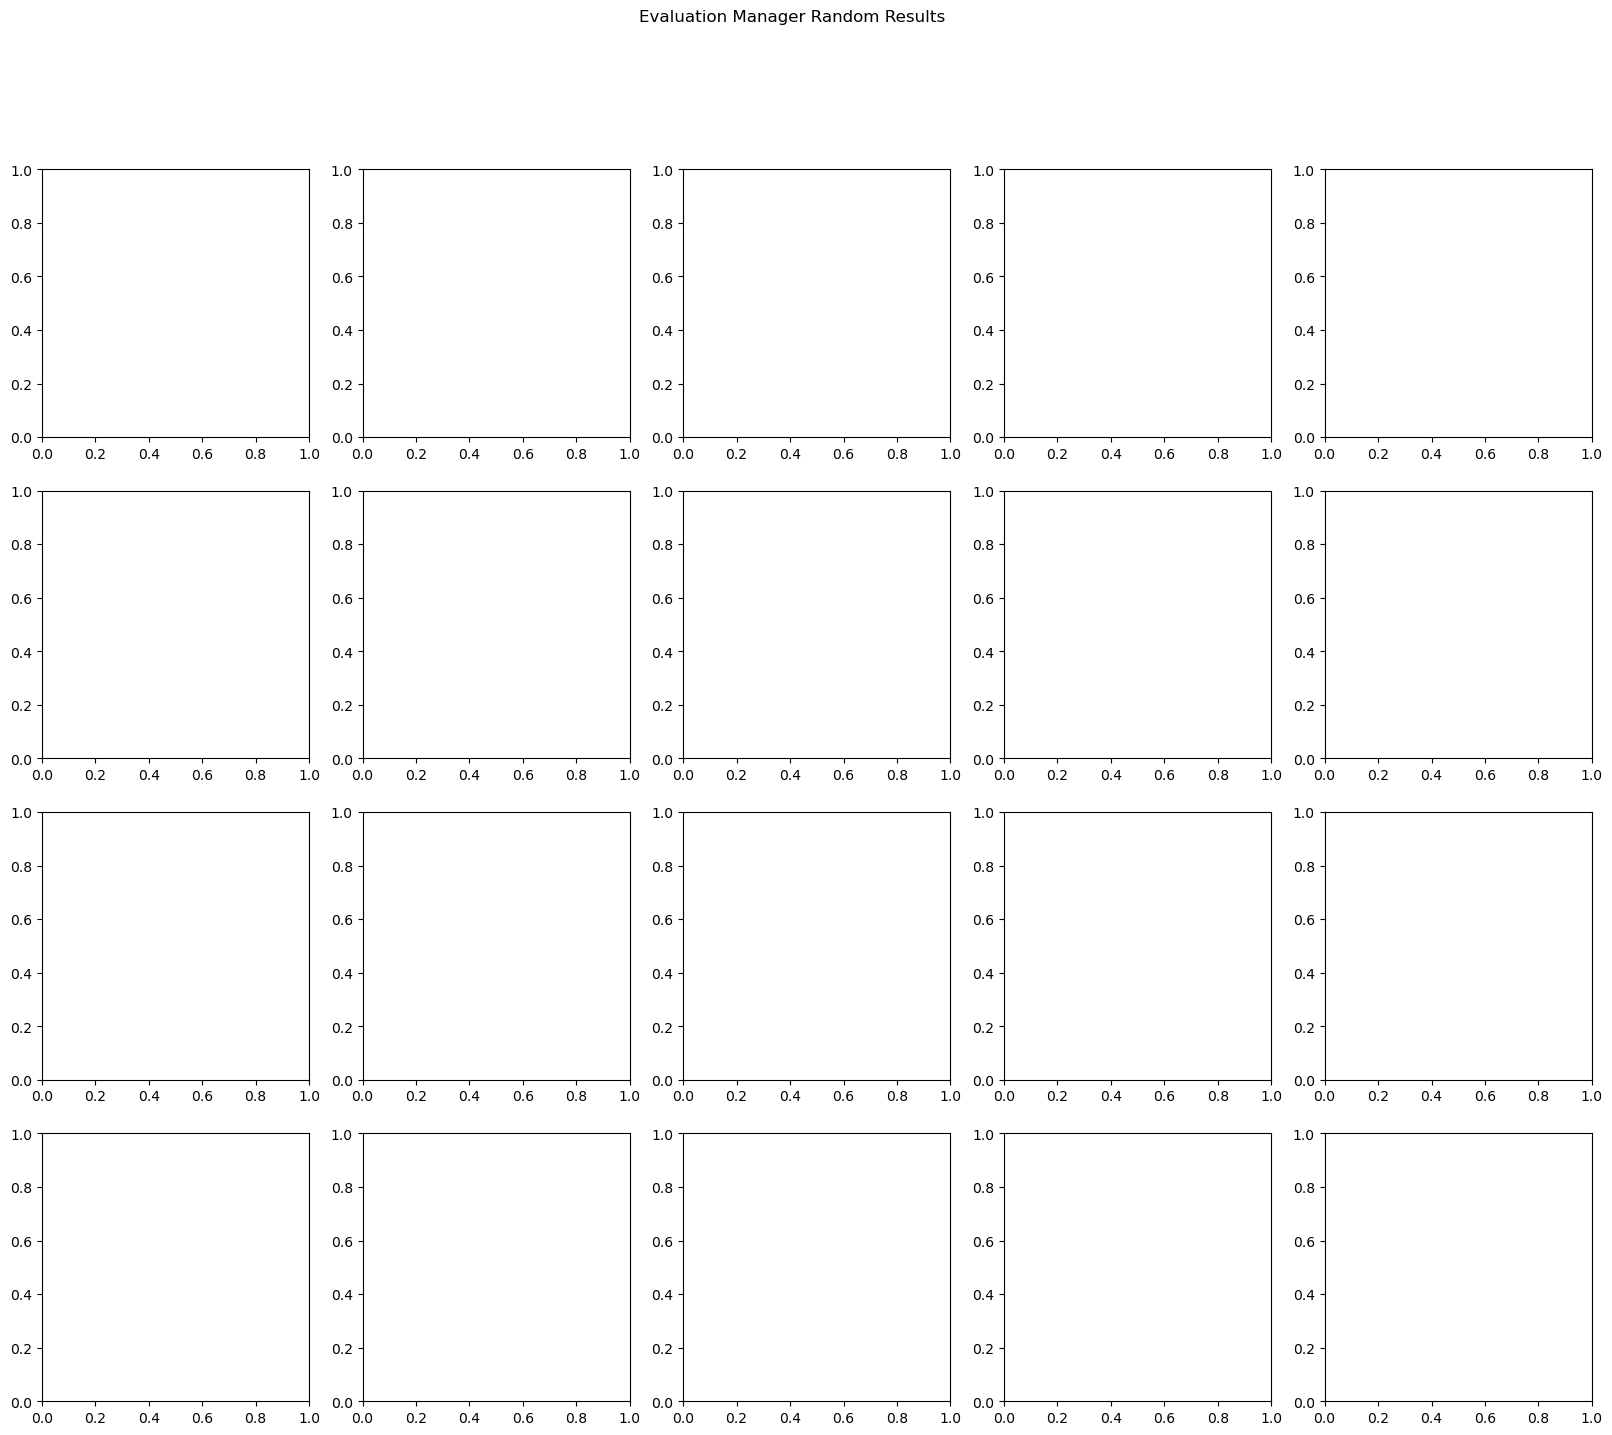

In [ ]:
class GeneticAlgorithm:
    """
    A generalized Genetic Algorithm class outline with integrated space management.
    """
    def __init__(self, ga_params: dict, fitness_function: callable, 
                 space_manager: SpaceManager, execution_manager: ExecutionManager):
        """
        ga_params_expected_keys: {
            'population_size': int,      # Size of the population
            'max_generations': int,      # Maximum number of generations
            'elitism': float,            # Percentage of best individuals to carry over
            'mutation_rate': float,      # Chance a gene will mutate
            'mutation_magnitude': float, # Magnitude of mutation chance
            'mutation_method': str,      # Mutation method to use
            'selection_method': str,     # Selection method to use
            'crossover_method': str,     # Crossover method to use
        }

        fitness_function: The function to optimize.
        space_manager: SpaceManager object to handle parameter space.
        execution_manager: ExecutionManager object to evaluate the fitness function.
        """

        logger.info(f"Initializing Graham's Genetic Algorithm")

        # Store the SpaceManager for parameter handling
        self.space_manager = space_manager
        self.space_info = self.space_manager.get_space()
        self.n_parameters = len(self.space_info)

        # Store GA configuration
        try:
            self.ga_params = ga_params
            self.population_size = ga_params['population_size']
            self.max_generations = ga_params['max_generations']
            self.mutation_rate = ga_params.get('mutation_rate', 1 / (1*self.n_parameters) ) # Default to 1 gene per individual
            self.mutation_magnitude = ga_params.get('mutation_magnitude', 0.1) # Default to 0.1 of available range
            self.mutation_method = ga_params.get('mutation_method', 'weighted_rank') # Default to random
            self.elitism = ga_params.get('elitism', self.population_size // 10) # Default to 10% of population
            self.selection_method = ga_params.get('selection_method', 'weighted_rank') # Default to weighted rank
            self.crossover_method = ga_params.get('crossover_method', 'uniform') # Default to uniform crossover
            self.init_pop_method = ga_params.get('init_pop_method', 'sobol') # Default to Sobol

        except KeyError as e:
            logger.error(f"Missing GA parameter: {e}")
            raise ValueError(f"Missing GA parameter: {e}")

        # Internal variables
        self.population_genes = None
        self.population_scores = None
        self.best_solution = None
        self.best_fitness = None

    #------------------------------------------------------------
    # Population Initialization
    #------------------------------------------------------------
    def initialize_population(self, pre_calculated=None):
        """
        Use or Generate an initial population of individuals.
        """

        # See if initialiat population was calculated elsewhere.

        



if buildEnv:

    logger.info(f"Testing Genetic Algorithm")

    test_space = [
        {'name':'uni-orig', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'identity'  }, # Working
        {'name':'log-orig', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'identity' }, # Working
        {'name':'uni-norm', 'type': 'float', 'bounds': [-4, 4], 'prior':'uniform', 'transform':'normalize' }, # Working
        {'name':'log-norm', 'type': 'float', 'bounds': [.01, 4], 'prior':'log-uniform', 'transform':'normalize' }, # Working
    ]
    space_manager = SpaceManager(test_space)
    test_function = lambda x: np.sum(x ** 2, axis=0)
    print("\nTest Function: Sum of Squares (sum(x^2))")
    
    # exec_manager = ExecutionManager(space_manager, black_box_function=test_function, normalize_output='log')
    exec_manager = ExecutionManager(space_manager, black_box_function=test_function, )
    
    # Set GA parameters
    ga_params_expected_keys: {
        'population_size': 100,
        'max_generations': 20,
        'mutation_rate': float,
        'selection_method': str,
        'crossover_method': str,
    }

    # Create subplot for each dimension
    fig, axs = plt.subplots(4, 5, figsize=(20, 16))

    # Set main title
    fig.suptitle("Evaluation Manager Random Results")

    # Histogram of original inputs
    for i, dim_info in enumerate(space_manager.space_info):
        exec_manager.hist_input(dim_index=i, space='original', external_ax=axs[0,i], title=f"Original Input: {dim_info['name']}")
        exec_manager.hist_input(dim_index=i, space='normalized', external_ax=axs[1,i], title=f"Normalized Input: {dim_info['name']}")
        exec_manager.scatter_input(dim_index=i, space='original', external_ax=axs[2,i], title=f"Orig In vs Out: {dim_info['name']}")
        exec_manager.scatter_input(dim_index=i, space='normalized', external_ax=axs[3,i], title=f"Norm In vs Out: {dim_info['name']}", output_log_scale=True)
    
    # Histogram of outputs
    exec_manager.hist_output(space='original', external_ax=axs[0,-1], title="Original Output")
    exec_manager.hist_output(space='normalized', external_ax=axs[1,-1], title="Normalized Output")
    
    # Setup Space Manager
    test_space = [
        {'name':'x1', 'type': 'float', 'bounds': [-10, 10], 'prior':'uniform', 'transform':'normalize'  },
        {'name':'x2', 'type': 'float', 'bounds': [-10, 10], 'prior':'uniform', 'transform':'normalize' }, 
    ]

    print("\nTesting Evaluation Manager with Input Space:")
    gu.pp(test_space)
    space_manager = SpaceManager(test_space)

    test_function = lambda x: np.sum(x ** 2) # Simple function, x=0 should be solution.
    print("\nTest Function: Sum of Squares")

    exec_manager = ExecutionManager(space_manager, black_box_function=test_function, normalize_output='log')

    # Validate the evaluation manager inputs/outputs are working correctly
    n = 10
    n_samples = space_manager.get_random_sample(n, space='normalized') # normalized samples
    n_outputs = exec_manager.evaluate_function(n_samples)

    # Test keys
    ga_params= {
        'population_size': 10,
        'max_generations': 5,
    }
    
    ga_manager = GeneticAlgorithm( ga_params = ga_params, fitness_function=test_function, space_manager=space_manager, execution_manager=exec_manager, )

    print(f"GA Manager: {ga_manager}")

    ga_manager.initialize_population()
    

In [ ]:
# reload gu
import importlib
gu = importlib.reload(gu)